In [3]:
!pip install ultralytics
!pip install numpy==1.26.4
import ultralytics
ultralytics.checks()

Ultralytics 8.3.241 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6586.5/8062.4 GB disk)


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Aijgqo8a2B5YfDiYvmTS")
project = rf.workspace("tsaannotation").project("brown-pods-bobqj")
version = project.version(1)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...


In [6]:
from ultralytics import YOLO
model=YOLO('/kaggle/input/brown-pods/brown_best.pt')

In [7]:
from ultralytics.nn.modules import Conv
from ultralytics.nn.tasks import SegmentationModel
import torch.nn as nn

class CBAM(nn.Module):
    def __init__(self, c1, reduction=16, k=7):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            Conv(c1, c1 // reduction, 1, act=nn.ReLU()),
            Conv(c1 // reduction, c1, 1, act=nn.Sigmoid()))
        self.sa = nn.Sequential(
            Conv(2, 1, k, p=k//2, act=nn.Sigmoid()))

    def forward(self, x):
        x = x * self.ca(x)
        avg = x.mean(1, keepdim=True)
        max = x.amax(1, keepdim=True)
        x = x * self.sa(torch.cat([avg, max], 1))
        return x

# monkey-patch: insert CBAM after every spatial pyramid layer
for m in model.model.modules():
    if isinstance(m, SegmentationModel):
        for i, (name, module) in enumerate(m.model.named_children()):
            if 'C2f' in module.__class__.__name__:   # P2/P3/P4/P5
                m.model[int(name)] = nn.Sequential(module, CBAM(module.conv[-1].out_channels))

In [8]:
from ultralytics import YOLO
model=YOLO('/kaggle/input/canola-grey/Grey_best (4).pt')          

In [7]:
import torch
torch.cuda.empty_cache()

In [ ]:

model.train(
    data='/kaggle/working/Brown-Pods-1/data.yaml',
    epochs=100,
    imgsz=1088,                 # squared, bigger tiles → more pods per tile
    batch=8,                  # larger batch → stabler gradients on small objs
    mosaic=0,                  # turn off mosaic (small objs get lost)
    copy_paste=0.6,            # best small-obj aug (ultralytics native)
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5,
    translate=0.1,
    scale=0.5,
    shear=0,
    perspective=0,
    flipud=0.0,
    fliplr=0.5,
    erasing=0.0,
    # crop_scale=0.0,
    optimizer='SGD',
    lr0=0.01,
    momentum=0.937,
    weight_decay=0.00005,      # no decay on BN (ultralytics default)
    warmup_epochs=5,
    warmup_momentum=0.8,
    cos_lr=True,
    patience=30,               # stop if seg-loss plateaus
    amp=True,                  # mixed precision
    optimize=True,             # torch.compile if GPU supports it
    device=[0,1],              # multi-GPU
    save_period=50,
    project='canola_brown_pod_seg',
)

Ultralytics 8.3.241 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.6, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Brown-Pods-1/data.yaml, degrees=5, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1088, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/brown-pods/brown_best.pt, momentum=0.937, mosaic=0, multi_scale=False, name=train, nbs=64, nms=Fal

Ultralytics 8.3.230 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Canola_rosette-2/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1088, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/model-second-best/4L_2nd_best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=trai

In [14]:
!ls /kaggle/working/runs/detect/train2

args.yaml			 labels.jpg	     train_batch381.jpg
BoxF1_curve.png			 results.csv	     train_batch382.jpg
BoxP_curve.png			 results.png	     val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg    val_batch0_pred.jpg
BoxR_curve.png			 train_batch1.jpg    weights
confusion_matrix_normalized.png  train_batch2.jpg
confusion_matrix.png		 train_batch380.jpg


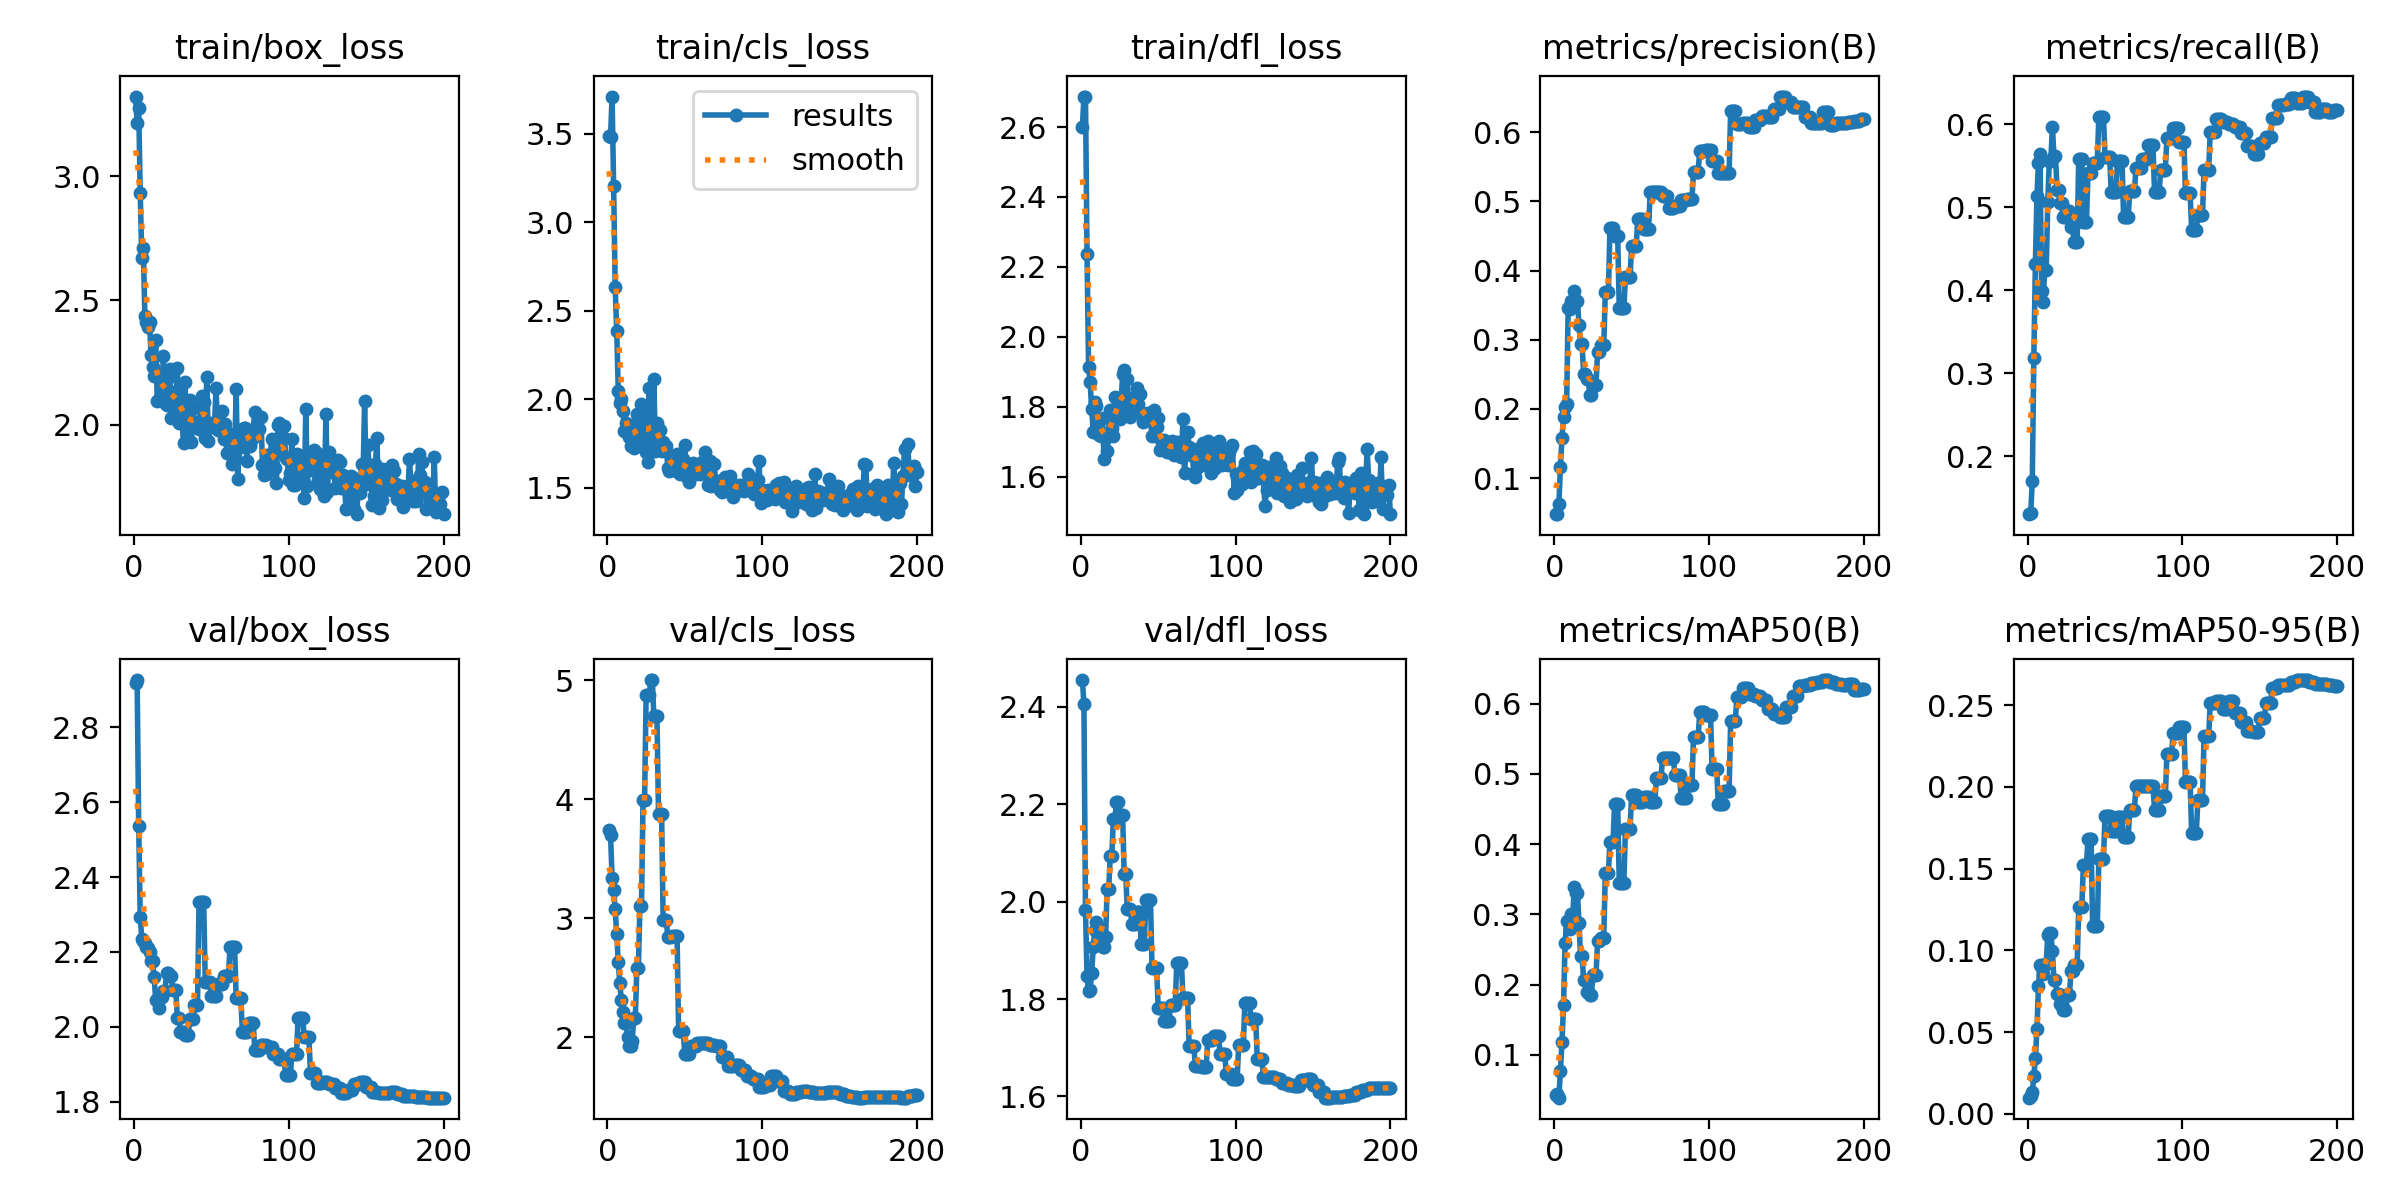

In [15]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/kaggle/working/runs/detect/train2/results.png', width=600)

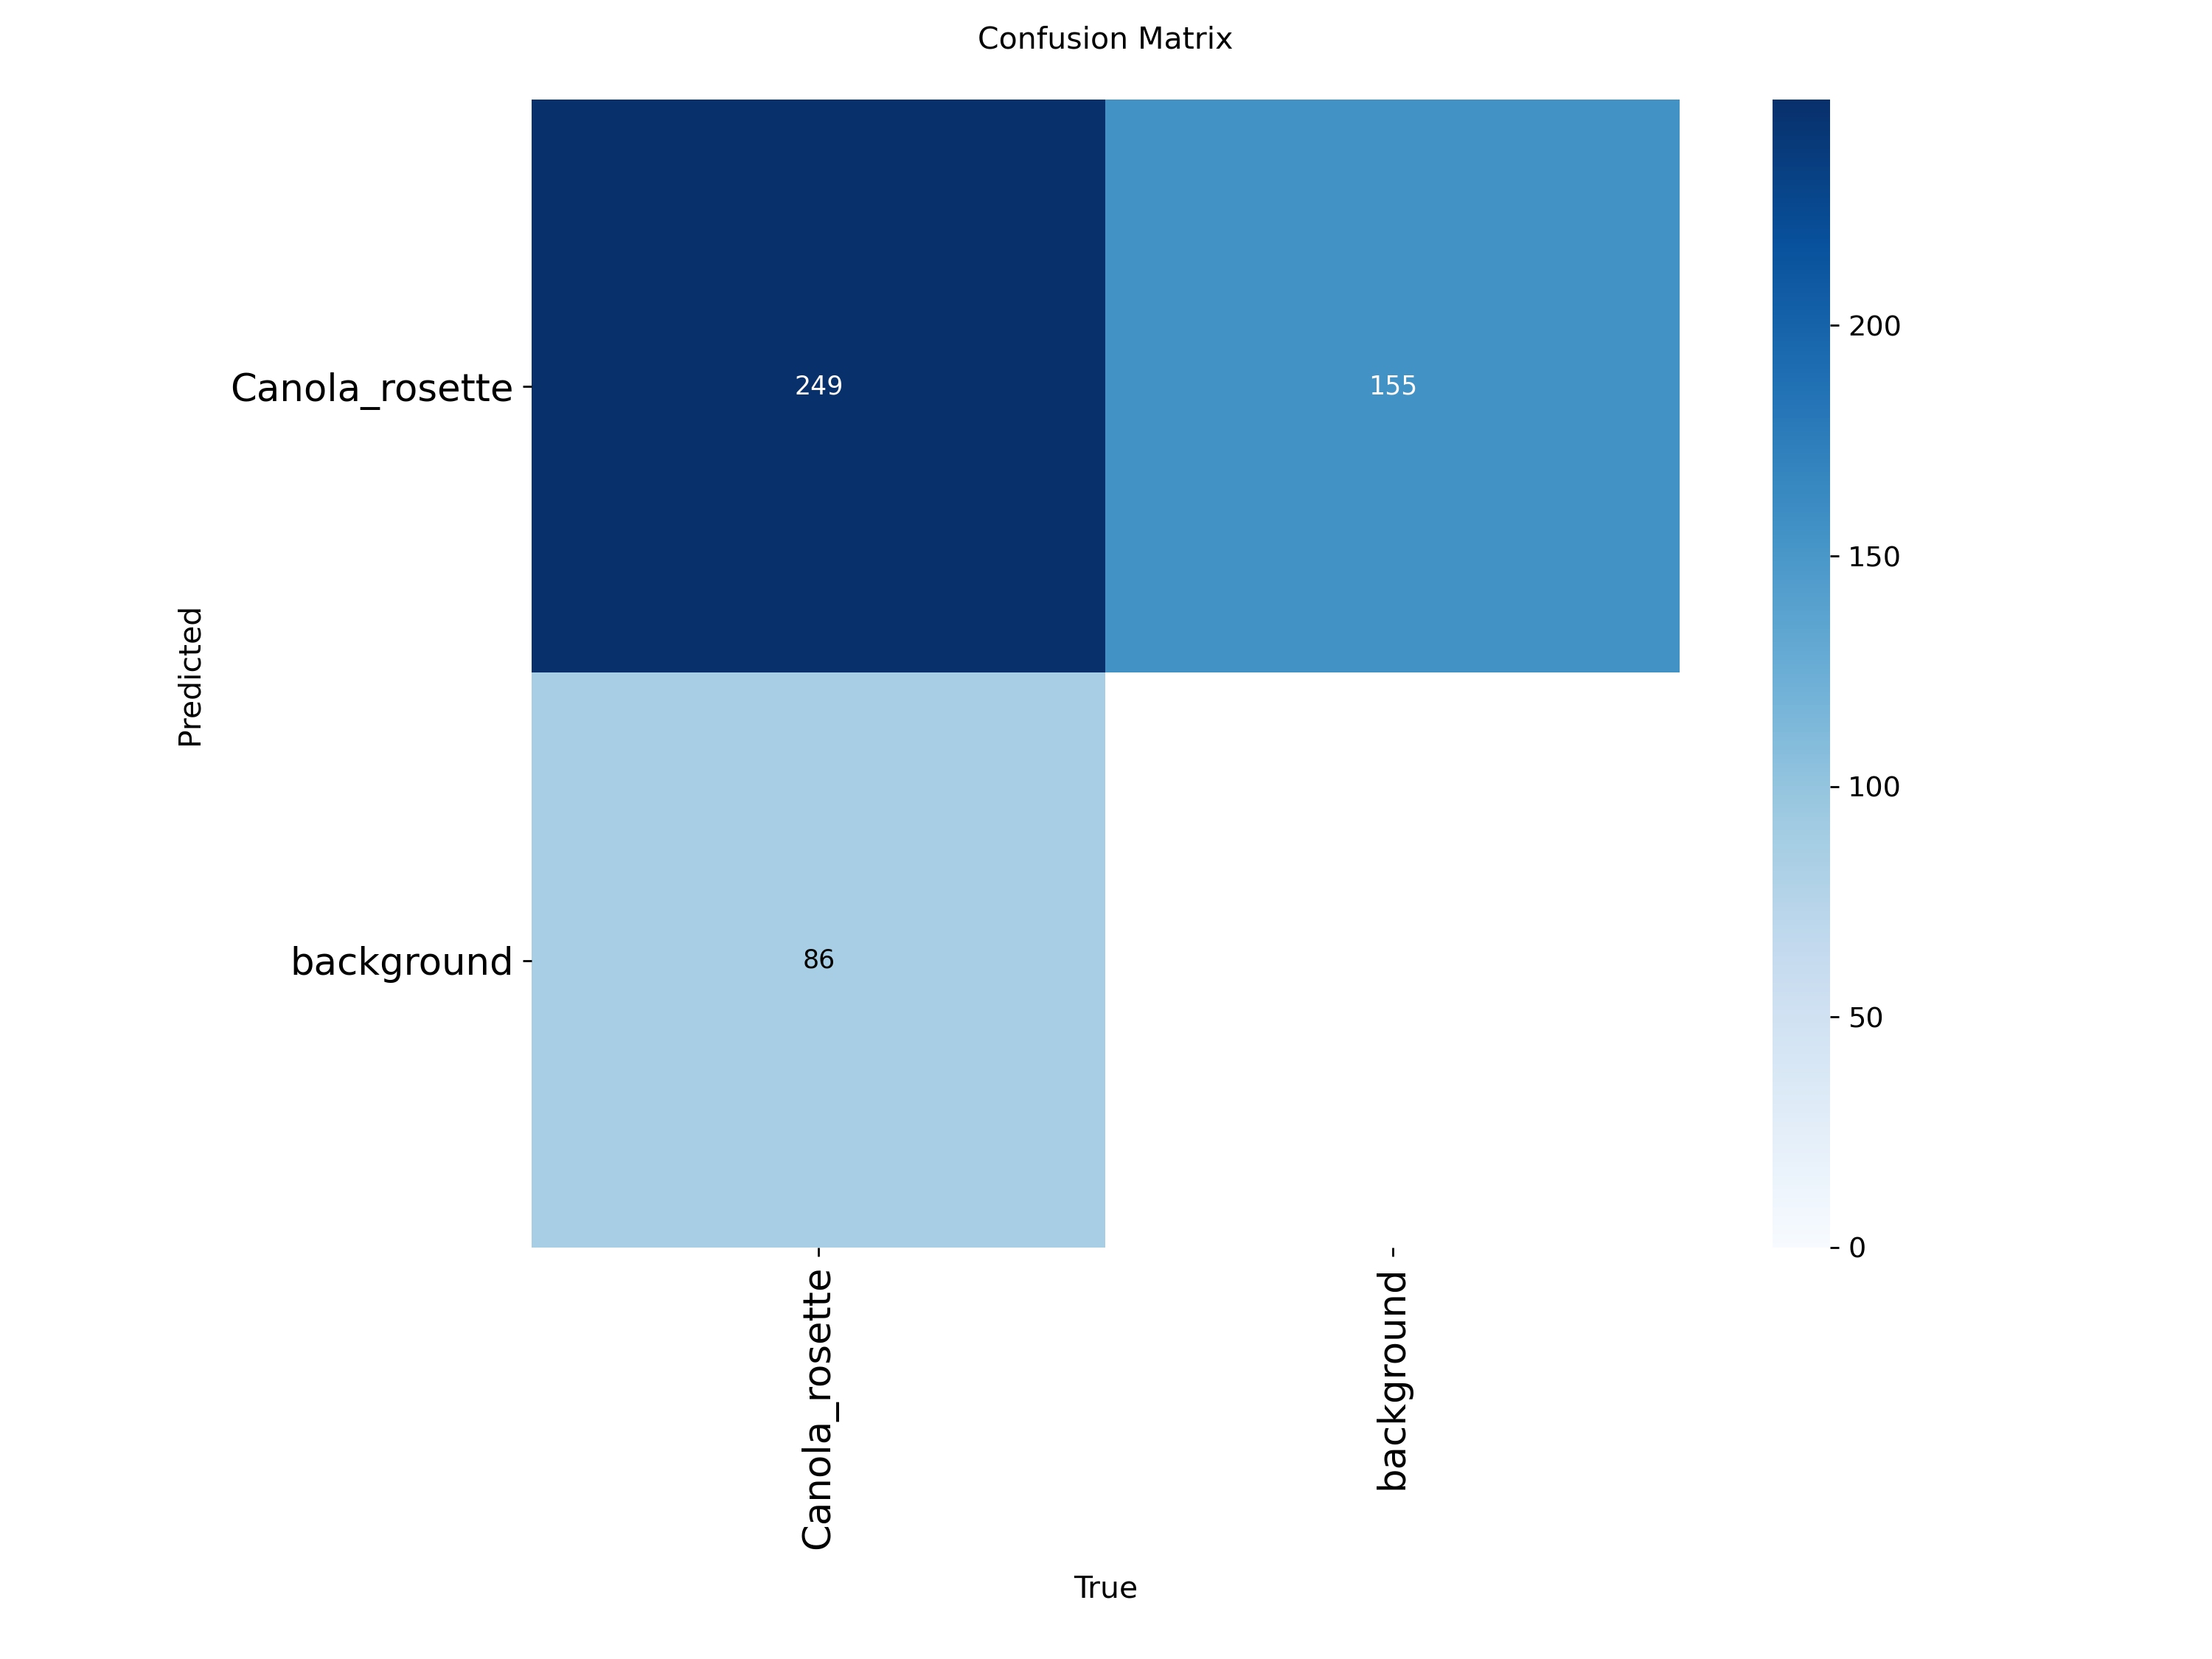

In [16]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/kaggle/working/runs/detect/train2/confusion_matrix.png', width=600)

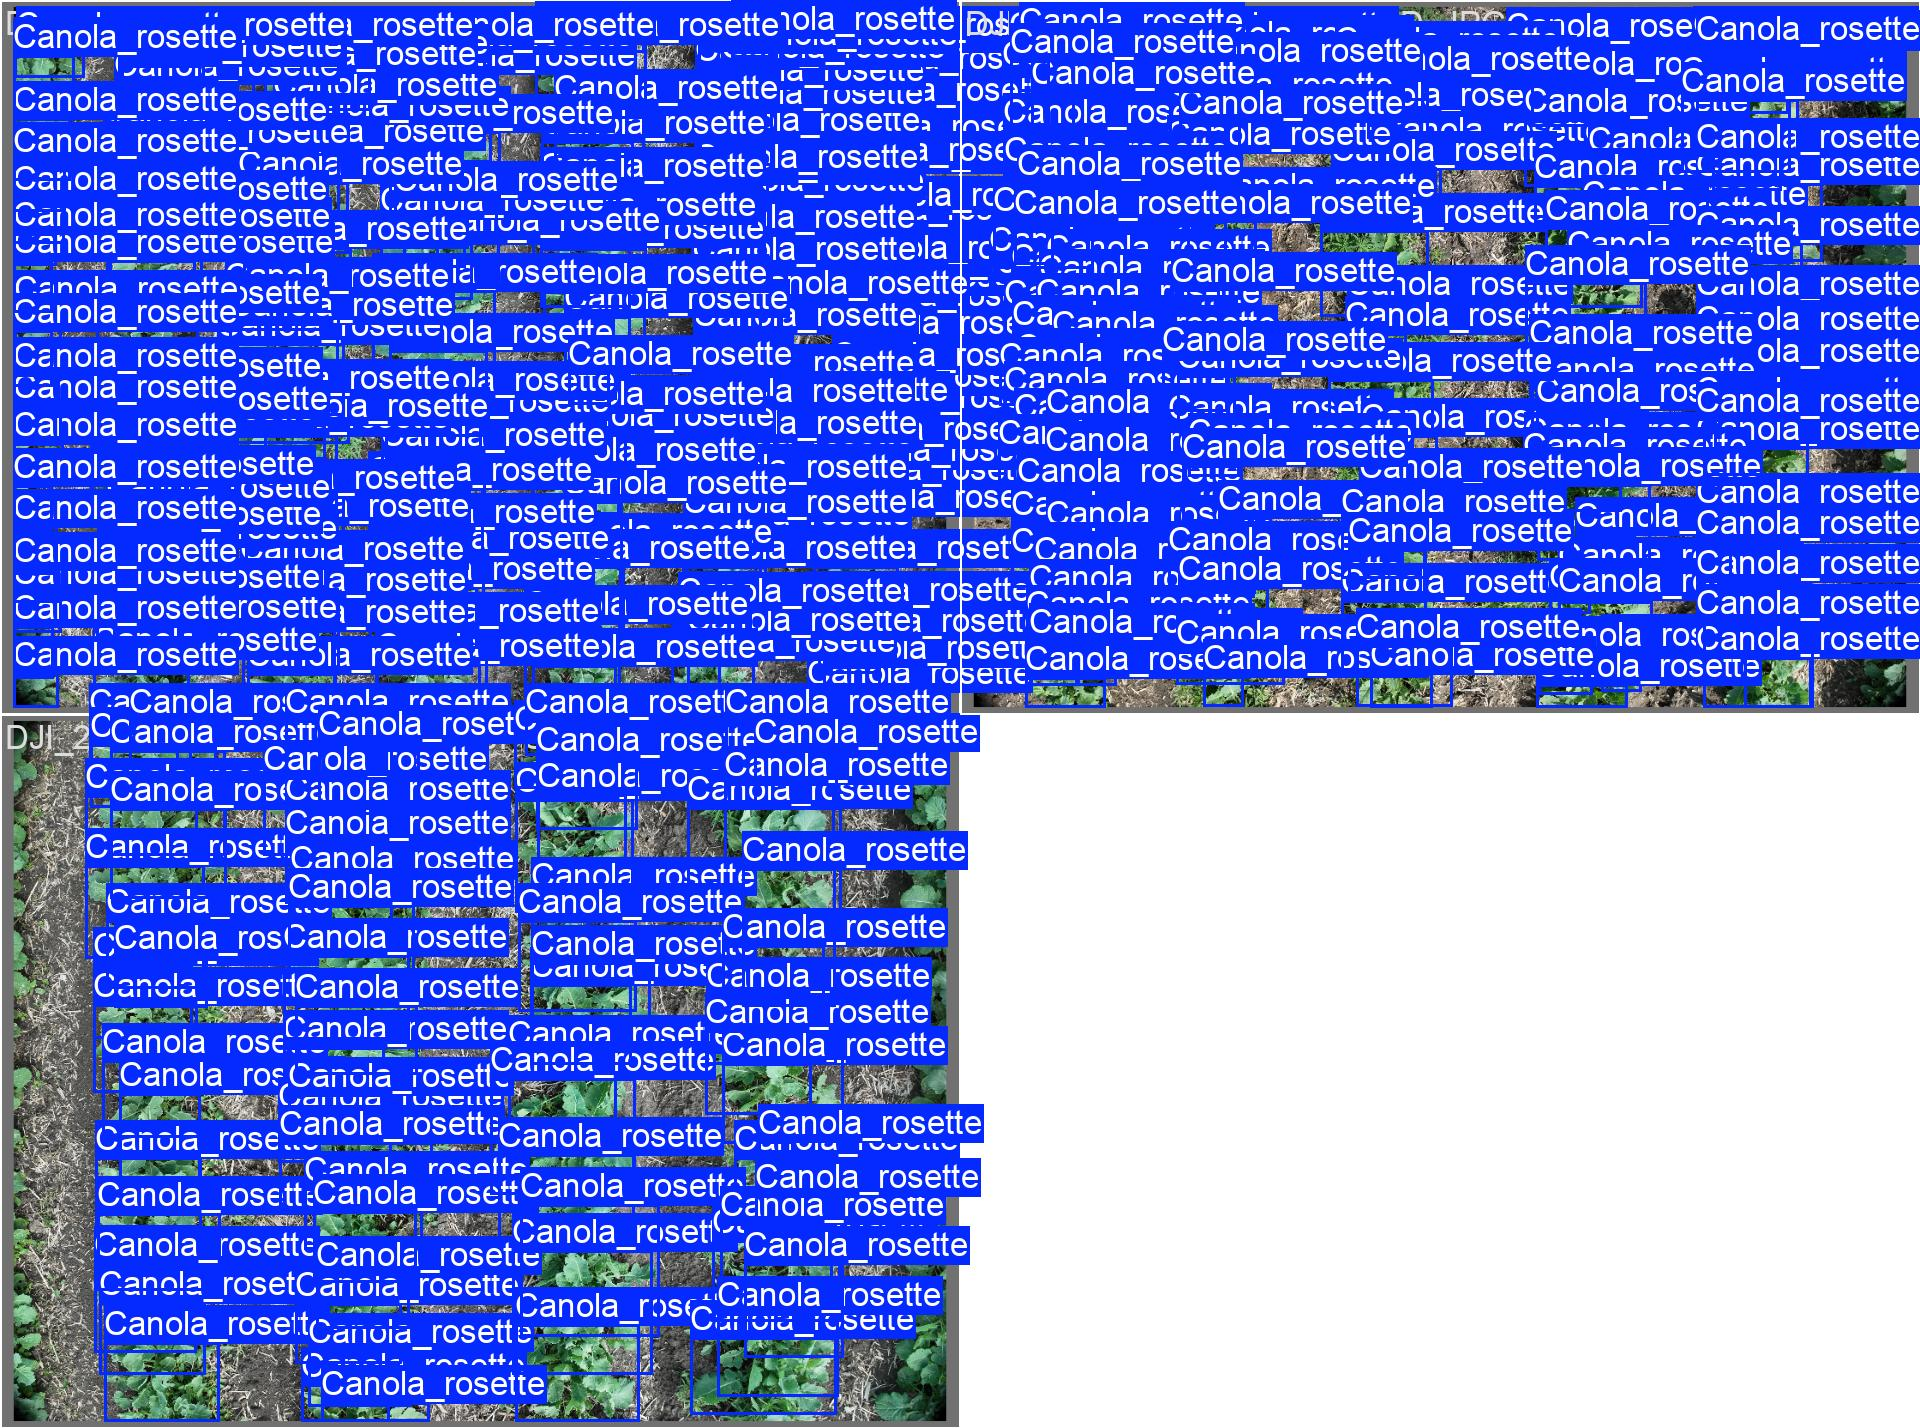

In [18]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'/kaggle/working/runs/detect/train2/val_batch0_labels.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml